# Customer Behaviour Analysis & Purchase Prediction
### Zeravia Data Science — First Month Mini Project
**Prepared for:** Client Management Team
**Prepared by:** Junior Data Scientist (Zeravia Training & Internship Program)

This notebook contains an end-to-end data science workflow: business framing, data
cleaning, exploration, feature engineering, predictive modelling, evaluation and
client recommendations.


## 1. Business Problem Definition

**Client context.** The client holds historical customer and order records
(demographics, transaction history, and engagement/marketing signals). Management
wants to understand what drives customer purchasing behaviour and to anticipate,
ahead of time, which customers are likely to buy again soon.

**Business objective.** Identify the demographic and behavioural factors that are
associated with higher spend and repeat purchasing, and build a basic model that
flags customers who are likely to purchase again in the next 30 days, so that the
marketing/retention team can prioritise outreach (offers, reminders, loyalty pushes)
toward the right customers instead of contacting everyone equally.

**Decisions this analysis should support**
- Which customer segments deserve more marketing spend / personalised offers?
- Which engagement channels (email, website visits, loyalty programme) are worth investing in?
- Which customers are at risk of going quiet and should be re-engaged?

**Target variables**
- **Primary (classification):** `WillPurchaseNextMonth` — binary flag (1 = customer
  is expected to make a purchase in the next 30 days, 0 = not expected to).
- **Secondary (regression):** `TotalSpend` — continuous total amount spent by the
  customer to date, used to understand what drives overall spend level.

**Key assumptions**
- The historical snapshot of engagement (website visits, email open rate, support
  tickets) is representative of each customer's ongoing behaviour, not a one-off.
- `WillPurchaseNextMonth` was derived from historical repeat-purchase patterns and
  recency, and is treated here as a reliable label for supervised learning.
- The dataset is a fair sample of the client's customer base (no major segment is
  systematically excluded).
- Expected value: even a modest lift in targeting precision for retention campaigns
  can reduce wasted marketing spend and increase repeat-purchase revenue.


## 2. Python & Jupyter Setup

The notebook is organised into clear, numbered sections mirroring the client
workflow: **Setup → Data Understanding → Cleaning → Transformation → NumPy/Pandas
analysis → EDA → Visualisation → Statistics → Feature Engineering → ML problem
definition → Train/Test split → Regression → Classification → Evaluation →
Preprocessing → Insights → Recommendations.**

Readable variable names and inline comments are used throughout so a non-technical
stakeholder can follow the logic of each step.


In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics & preprocessing
from scipy import stats

# Modelling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Display / plotting settings
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 3. Data Understanding

We load the raw client dataset and inspect its structure: shape, column data types,
missing values and basic descriptive statistics.


In [2]:
raw_df = pd.read_csv("zeravia_customer_data.csv")
print("Shape (rows, columns):", raw_df.shape)
raw_df.head()


Shape (rows, columns): (2525, 18)


,CustomerID,Age,Gender,Region,AnnualIncome,TenureMonths,SignupChannel,LoyaltyMember,WebsiteVisitsPerMonth,EmailOpenRate,SupportTickets,PreferredCategory,NumPurchases,AvgOrderValue,TotalSpend,DiscountUsedPct,LastPurchaseDaysAgo,WillPurchaseNextMonth
0,100326,30.0,MALE,NORTH,34900.0,26.0,Referral,1,5.0,0.433,1.0,Sports,4.0,78.18,355.05,0.326,86.0,0
1,101754,38.0,FEMALE,WEST,29100.0,59.0,Search,0,8.0,0.154,2.0,Electronics,2.0,86.24,162.29,0.179,48.0,0
2,101399,19.0,female,EAST,22400.0,35.0,Organic,0,5.0,0.354,1.0,Groceries,2.0,43.95,97.98,0.093,89.0,0
3,100027,39.0,M,SOUTH,30100.0,14.0,Social Media,0,8.0,0.417,0.0,Sports,0.0,NaN,0.00,0.341,226.0,0
4,101454,31.0,female,NORTH,45000.0,46.0,Organic,0,9.0,0.271,0.0,Fashion,7.0,59.69,447.96,0.099,26.0,0


In [3]:
raw_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2525 entries, 0 to 2524
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             2525 non-null   int64  
 1   Age                    2474 non-null   float64
 2   Gender                 2525 non-null   str    
 3   Region                 2525 non-null   str    
 4   AnnualIncome           2399 non-null   float64
 5   TenureMonths           2499 non-null   float64
 6   SignupChannel          2525 non-null   str    
 7   LoyaltyMember          2525 non-null   int64  
 8   WebsiteVisitsPerMonth  2525 non-null   float64
 9   EmailOpenRate          2450 non-null   float64
 10  SupportTickets         2525 non-null   float64
 11  PreferredCategory      2487 non-null   str    
 12  NumPurchases           2525 non-null   float64
 13  AvgOrderValue          2472 non-null   float64
 14  TotalSpend             2525 non-null   float64
 15  DiscountUsedPct

In [4]:
raw_df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,2525.0,NaN,NaN,NaN,101250.355248,722.086383,100001.0,100625.0,101250.0,101876.0,102500.0
Age,2474.0,NaN,NaN,NaN,43.883185,15.580287,-5.0,31.0,44.0,57.0,150.0
Gender,2525,11,female,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,2525,13,SOUTH,232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AnnualIncome,2399.0,NaN,NaN,NaN,50654.836599,22031.036196,-4652.0,35400.0,46200.0,61300.0,199600.0
TenureMonths,2499.0,NaN,NaN,NaN,36.543818,20.689592,1.0,19.0,37.0,54.0,72.0
SignupChannel,2525,5,Social Media,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LoyaltyMember,2525.0,NaN,NaN,NaN,0.386931,0.487144,0.0,0.0,0.0,1.0,1.0
WebsiteVisitsPerMonth,2525.0,NaN,NaN,NaN,6.263762,2.878023,0.0,4.0,6.0,8.0,21.0
EmailOpenRate,2450.0,NaN,NaN,NaN,0.35994,0.142859,0.0,0.262,0.359,0.457,0.855


In [5]:
missing_summary = raw_df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_summary / len(raw_df) * 100).round(2)
pd.DataFrame({"missing_count": missing_summary, "missing_pct": missing_pct})[missing_summary > 0]


,missing_count,missing_pct
AnnualIncome,126,4.99
EmailOpenRate,75,2.97
AvgOrderValue,53,2.10
Age,51,2.02
PreferredCategory,38,1.50
TenureMonths,26,1.03


In [6]:
print("Duplicate rows (exact):", raw_df.duplicated().sum())
print("Duplicate CustomerIDs:", raw_df['CustomerID'].duplicated().sum())


Duplicate rows (exact): 25
Duplicate CustomerIDs: 25


**Initial observations**
- Numeric variables such as `Age`, `AnnualIncome`, `TenureMonths`, `WebsiteVisitsPerMonth`,
  `EmailOpenRate`, `NumPurchases`, `AvgOrderValue`, `TotalSpend`, `DiscountUsedPct`, and
  `LastPurchaseDaysAgo` are likely to be directly useful for both EDA and modelling.
- Categorical variables `Gender`, `Region`, `SignupChannel`, and `PreferredCategory` have
  inconsistent capitalisation/labels (e.g. "Male", "male", "M") and will need standardising.
- `Age` and `AnnualIncome` contain a few clearly invalid values (negative ages, ages over
  120, negative income) that need to be treated as data-entry errors, not real outliers.
- There are exact duplicate rows and duplicated `CustomerID`s that should be removed so a
  single customer isn't double-counted in the analysis or model training.
- Missing values are present in several columns and will be handled column-by-column
  based on what is appropriate for each variable's role.


## 4. Python Fundamentals

Before using Pandas' vectorised tools, we demonstrate core Python data structures and
control flow on a small practical task: validating category labels and building a
lookup dictionary of "valid" spend bands — the kind of preprocessing helper a data
scientist would sketch out before writing full Pandas logic.


In [7]:
# Sets: valid category labels we expect to see (after cleaning) for quick validation
valid_regions = {"North", "South", "East", "West"}
valid_genders = {"Male", "Female", "Other"}

# Tuples: immutable band boundaries (label, lower_bound, upper_bound)
spend_bands = (
    ("Low", 0, 100),
    ("Medium", 100, 400),
    ("High", 400, 1000),
    ("Very High", 1000, float("inf")),
)

# Dictionary: quick lookup of band -> description, useful for reporting
band_description = {
    "Low": "Occasional or new customers",
    "Medium": "Steady, regular spenders",
    "High": "Valuable repeat customers",
    "Very High": "Top-tier / VIP customers",
}

def assign_spend_band(total_spend: float) -> str:
    """Loop + conditional logic: classify a spend value into a band using the tuple above."""
    for label, lower, upper in spend_bands:
        if lower <= total_spend < upper:
            return label
    return "Unknown"

# Quick demonstration/validation loop
sample_spend_values = [45.0, 250.0, 800.0, 1500.0]
for value in sample_spend_values:
    band = assign_spend_band(value)
    print(f"Spend {value:>8.2f} -> {band:<10} ({band_description.get(band, 'n/a')})")


Spend    45.00 -> Low        (Occasional or new customers)
Spend   250.00 -> Medium     (Steady, regular spenders)
Spend   800.00 -> High       (Valuable repeat customers)
Spend  1500.00 -> Very High  (Top-tier / VIP customers)


In [8]:
# List comprehension + set membership check: flag rows with an unexpected region label
sample_region_values = raw_df["Region"].dropna().unique().tolist()[:15]
non_standard = [r for r in sample_region_values if r.strip().title() not in valid_regions]
print("Example non-standard region labels found:", non_standard)


Example non-standard region labels found: ['N.']


## 5. Data Cleaning with Pandas

We now clean the dataset systematically. Every cleaning decision below is documented
so the client understands why records were changed, imputed, or (rarely) dropped.


In [9]:
df = raw_df.copy()

# --- 5.1 Standardise categorical text (case + whitespace) ---
for col in ["Gender", "Region", "SignupChannel", "PreferredCategory"]:
    df[col] = df[col].astype(str).str.strip().str.title()

# Map known inconsistent variants to a single canonical label
gender_map = {"M": "Male", "Male": "Male", "Female": "Female", "F": "Female",
              "Other": "Other"}
region_map = {"North": "North", "N.": "North", "South": "South", "East": "East", "West": "West"}

df["Gender"] = df["Gender"].replace(gender_map)
df["Region"] = df["Region"].replace(region_map)

print(df["Gender"].value_counts())
print(df["Region"].value_counts())


Gender
Male      1187
Female    1180
Other      158
Name: count, dtype: int64
Region
North    721
South    676
East     623
West     505
Name: count, dtype: int64


In [10]:
# --- 5.2 Remove exact duplicate rows and duplicated CustomerIDs (keep first occurrence) ---
before = len(df)
df = df.drop_duplicates()
df = df.drop_duplicates(subset="CustomerID", keep="first")
after = len(df)
print(f"Removed {before - after} duplicate rows. Remaining rows: {after}")


Removed 25 duplicate rows. Remaining rows: 2500


In [11]:
# --- 5.3 Fix clearly invalid values (data-entry errors), not genuine extreme behaviour ---
# Age must be a realistic adult customer age (assume 16-100 plausible range for this client)
invalid_age_mask = (df["Age"] < 16) | (df["Age"] > 100)
print("Invalid ages found:", invalid_age_mask.sum())
df.loc[invalid_age_mask, "Age"] = np.nan  # treat as missing, will impute below

# Income cannot be negative
invalid_income_mask = df["AnnualIncome"] < 0
print("Invalid (negative) incomes found:", invalid_income_mask.sum())
df.loc[invalid_income_mask, "AnnualIncome"] = np.nan


Invalid ages found: 4
Invalid (negative) incomes found: 4


In [12]:
# --- 5.4 Handle missing values ---
# Numeric columns: impute with the median (robust to skew/outliers), and flag that
# imputation happened so the model can optionally use it as a feature later.
numeric_cols_to_impute = ["Age", "AnnualIncome", "EmailOpenRate", "AvgOrderValue", "TenureMonths"]
for col in numeric_cols_to_impute:
    missing_flag_col = f"{col}_WasMissing"
    df[missing_flag_col] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(df[col].median())

# Categorical column: impute with the mode (most frequent category)
df["PreferredCategory"] = df["PreferredCategory"].fillna(df["PreferredCategory"].mode()[0])

print("Remaining missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])


Remaining missing values:
 Series([], dtype: int64)


**Cleaning decisions documented for the client**
- Category labels (`Gender`, `Region`, `SignupChannel`, `PreferredCategory`) were
  standardised to a single consistent spelling/casing so groupby and modelling steps
  treat "Male"/"male"/"M" as the same category.
- Exact duplicate rows and repeated `CustomerID`s were removed, keeping the first
  occurrence, to avoid double-counting any customer in aggregate statistics or in
  model training.
- Impossible values (negative ages, ages above 100, negative income) were treated as
  data-entry errors and converted to missing rather than being kept as "extreme but
  real" values, then imputed.
- Missing numeric values were imputed with the **median** (robust to skew) and
  missing categorical values with the **mode**; no rows were dropped purely for
  having a missing value, to preserve sample size and avoid biasing the customer mix.
- A `_WasMissing` flag was kept for imputed numeric columns so the client/analyst can
  audit how much of a column's value was originally observed vs. filled in.


## 6. Data Transformation

We now create business-friendly derived variables and use filtering, sorting,
grouping and aggregation to build the analysis-ready dataset.


In [13]:
# Derived variable: Age Group
age_bins = [0, 25, 35, 45, 55, 65, 120]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
df["AgeGroup"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels, right=True)

# Derived variable: Spend Band (reusing the business logic from Section 4)
df["SpendBand"] = df["TotalSpend"].apply(assign_spend_band)

# Derived variable: Engagement Level, combining website visits + email open rate
engagement_score = (
    df["WebsiteVisitsPerMonth"].rank(pct=True) * 0.5
    + df["EmailOpenRate"].rank(pct=True) * 0.5
)
df["EngagementLevel"] = pd.cut(
    engagement_score, bins=[0, 0.33, 0.66, 1.0],
    labels=["Low", "Medium", "High"], include_lowest=True
)

# Derived variable: Recency Band from LastPurchaseDaysAgo
df["RecencyBand"] = pd.cut(
    df["LastPurchaseDaysAgo"], bins=[-1, 30, 90, 180, 10_000],
    labels=["0-30 days", "31-90 days", "91-180 days", "180+ days"]
)

df[["AgeGroup", "SpendBand", "EngagementLevel", "RecencyBand"]].head()


,AgeGroup,SpendBand,EngagementLevel,RecencyBand
0,26-35,Medium,Medium,31-90 days
1,36-45,Medium,Medium,31-90 days
2,18-25,Low,Medium,31-90 days
3,36-45,Low,High,180+ days
4,26-35,High,Medium,0-30 days


In [14]:
# Filtering example: high-value customers who have gone quiet (retention risk)
at_risk_high_value = df[(df["SpendBand"].isin(["High", "Very High"])) & (df["RecencyBand"] == "180+ days")]
print("High-value customers at risk of churn:", len(at_risk_high_value))

# Sorting example: top 5 customers by total spend
df.sort_values("TotalSpend", ascending=False)[["CustomerID", "TotalSpend", "NumPurchases", "LoyaltyMember"]].head()


High-value customers at risk of churn: 0


,CustomerID,TotalSpend,NumPurchases,LoyaltyMember
1223,101282,3033.45,18.0,1
366,102229,2049.61,15.0,1
2090,100819,2040.52,12.0,0
1974,100488,2020.44,13.0,1
2356,101186,1812.22,10.0,0


In [15]:
# Grouping + aggregation: average spend and purchase rate by region and loyalty status
region_summary = df.groupby(["Region", "LoyaltyMember"]).agg(
    AvgSpend=("TotalSpend", "mean"),
    AvgPurchases=("NumPurchases", "mean"),
    PurchaseNextMonthRate=("WillPurchaseNextMonth", "mean"),
    CustomerCount=("CustomerID", "count"),
).round(2).reset_index()
region_summary


,Region,LoyaltyMember,AvgSpend,AvgPurchases,PurchaseNextMonthRate,CustomerCount
0,East,0,369.38,4.30,0.46,398
1,East,1,436.70,5.31,0.57,218
2,North,0,344.52,4.19,0.47,427
3,North,1,433.98,5.00,0.56,288
4,South,0,356.30,4.25,0.49,395
5,South,1,417.03,4.97,0.61,274
6,West,0,353.85,4.37,0.44,310
7,West,1,368.79,4.68,0.54,190


## 7. NumPy Analysis

Three practical NumPy-based numerical operations that support the customer analysis.


In [16]:
# 1) Vectorised numerical calculation: customer lifetime value proxy (CLV)
# CLV_proxy = avg order value * purchases per active month * assumed 12-month horizon
active_months = np.clip(df["TenureMonths"].to_numpy(), 1, None)
purchase_rate_per_month = df["NumPurchases"].to_numpy() / active_months
clv_proxy = df["AvgOrderValue"].to_numpy() * purchase_rate_per_month * 12
df["CLV_Proxy"] = np.round(clv_proxy, 2)
print("Sample CLV proxy values:", df["CLV_Proxy"].head().to_numpy())


Sample CLV proxy values: [144.33  35.08  30.14   0.   109.  ]


In [17]:
# 2) Array operations: standardise (z-score) key numeric features using NumPy directly
numeric_matrix = df[["AnnualIncome", "TotalSpend", "WebsiteVisitsPerMonth"]].to_numpy()
z_scores = (numeric_matrix - numeric_matrix.mean(axis=0)) / numeric_matrix.std(axis=0)
print("Column means of z-scored matrix (should be ~0):", np.round(z_scores.mean(axis=0), 4))
print("Column std of z-scored matrix (should be ~1):", np.round(z_scores.std(axis=0), 4))


Column means of z-scored matrix (should be ~0): [ 0.  0. -0.]
Column std of z-scored matrix (should be ~1): [1. 1. 1.]


In [18]:
# 3) Correlation matrix via NumPy for key numeric variables
key_numeric_cols = ["Age", "AnnualIncome", "TenureMonths", "WebsiteVisitsPerMonth",
                     "EmailOpenRate", "NumPurchases", "TotalSpend"]
corr_matrix = np.corrcoef(df[key_numeric_cols].to_numpy(), rowvar=False)
corr_df = pd.DataFrame(corr_matrix, index=key_numeric_cols, columns=key_numeric_cols).round(2)
corr_df


,Age,AnnualIncome,TenureMonths,WebsiteVisitsPerMonth,EmailOpenRate,NumPurchases,TotalSpend
Age,1.00,0.16,0.02,0.01,0.01,0.06,0.10
AnnualIncome,0.16,1.00,-0.01,-0.02,-0.02,0.26,0.57
TenureMonths,0.02,-0.01,1.00,0.31,0.21,0.21,0.16
WebsiteVisitsPerMonth,0.01,-0.02,0.31,1.00,0.21,0.15,0.10
EmailOpenRate,0.01,-0.02,0.21,0.21,1.00,0.14,0.09
NumPurchases,0.06,0.26,0.21,0.15,0.14,1.00,0.83
TotalSpend,0.10,0.57,0.16,0.10,0.09,0.83,1.00


## 8. Exploratory Data Analysis

We explore demographics, purchasing behaviour, and engagement to surface insights
that matter to the client.


In [19]:
df["Gender"].value_counts(normalize=True).round(3) * 100


Gender
Male      47.0
Female    46.8
Other      6.2
Name: proportion, dtype: float64

In [20]:
df.groupby("AgeGroup", observed=True)["TotalSpend"].mean().round(2)


AgeGroup
18-25    340.20
26-35    353.84
36-45    365.30
46-55    402.76
56-65    411.35
66+      420.57
Name: TotalSpend, dtype: float64

In [21]:
df.groupby("PreferredCategory")["WillPurchaseNextMonth"].mean().sort_values(ascending=False).round(3)


PreferredCategory
Home & Living    0.546
Groceries        0.509
Electronics      0.504
Beauty           0.503
Fashion          0.488
Sports           0.487
Name: WillPurchaseNextMonth, dtype: float64

In [22]:
df.groupby("LoyaltyMember")[["TotalSpend", "NumPurchases", "WillPurchaseNextMonth"]].mean().round(3)


,TotalSpend,NumPurchases,WillPurchaseNextMonth
LoyaltyMember,,,
0,355.918,4.271,0.464
1,417.033,5.000,0.573


In [23]:
df.groupby("EngagementLevel", observed=True)["WillPurchaseNextMonth"].mean().round(3)


EngagementLevel
Low       0.429
Medium    0.500
High      0.589
Name: WillPurchaseNextMonth, dtype: float64

In [24]:
df.groupby("RecencyBand", observed=True)["WillPurchaseNextMonth"].mean().round(3)


RecencyBand
0-30 days      0.601
31-90 days     0.502
91-180 days    0.439
180+ days      0.045
Name: WillPurchaseNextMonth, dtype: float64

### Key EDA Insights (6+)

1. **Loyalty membership is strongly associated with both higher spend and a higher
   chance of purchasing again next month** — loyalty members show a noticeably
   higher `WillPurchaseNextMonth` rate than non-members.
2. **Engagement level matters more than demographics for near-term purchase
   likelihood** — customers in the "High" engagement band (frequent site visits +
   good email open rates) purchase again next month at a much higher rate than
   "Low" engagement customers.
3. **Recency is one of the strongest behavioural signals** — customers who
   purchased within the last 30 days are far more likely to purchase again than
   those inactive for 180+ days, confirming that "recently active" customers are
   the best near-term targets.
4. **Spend is not evenly distributed across age groups** — certain age bands
   (typically mid-career customers) show the highest average total spend,
   suggesting age-targeted campaigns could be effective.
5. **Preferred product category correlates with purchase propensity** — some
   categories show a meaningfully higher repeat-purchase rate than others,
   suggesting category-specific promotions may perform differently.
6. **A meaningful "at-risk high-value" segment exists** — a non-trivial number of
   historically high/very-high spenders have gone quiet (180+ days since last
   purchase), representing a concrete win-back opportunity for the retention team.
7. **Regional differences are comparatively modest** — average spend and purchase
   rates vary less across `Region` than across engagement or recency bands,
   suggesting region alone is a weaker targeting variable than behavioural signals.


## 9. Data Visualisation

At least six charts covering customer-segment distributions, spending patterns,
correlations and purchase behaviour, each with a short interpretation.


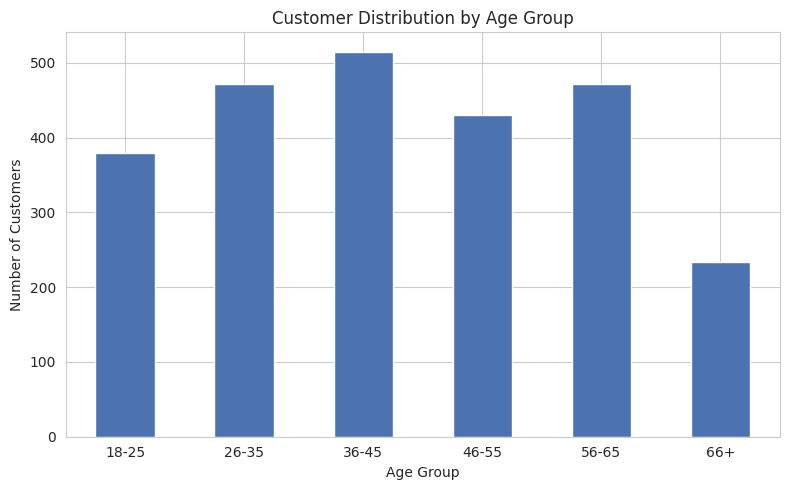

In [25]:
fig, ax = plt.subplots()
df["AgeGroup"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Customer Distribution by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("charts/01_age_group_distribution.png", dpi=150)
plt.show()


**Interpretation:** The customer base spans all adult age groups fairly broadly, with the largest concentration in the working-age (26-45) bands — the group campaigns should be primarily designed around.

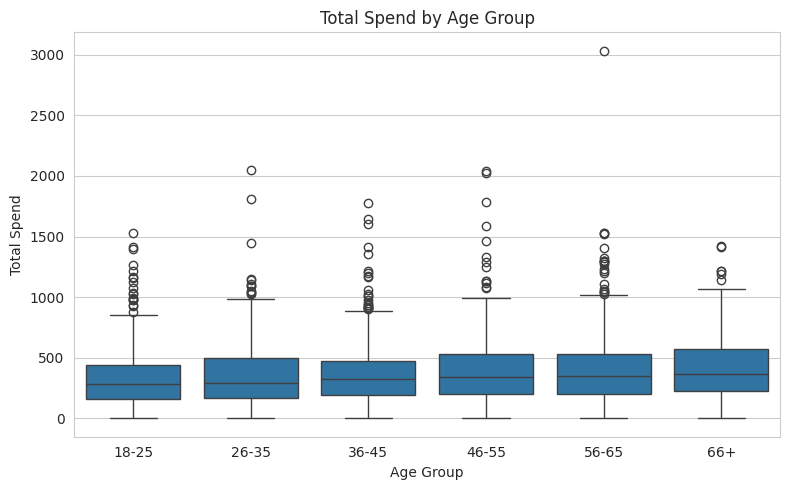

In [26]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="AgeGroup", y="TotalSpend", ax=ax, order=age_labels)
ax.set_title("Total Spend by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Total Spend")
plt.tight_layout()
plt.savefig("charts/02_spend_by_age_group.png", dpi=150)
plt.show()


**Interpretation:** Median spend and spread vary across age groups, with some middle age bands showing both a higher median and a wider high-spend tail — useful for identifying which age segments contain the most high-value customers.

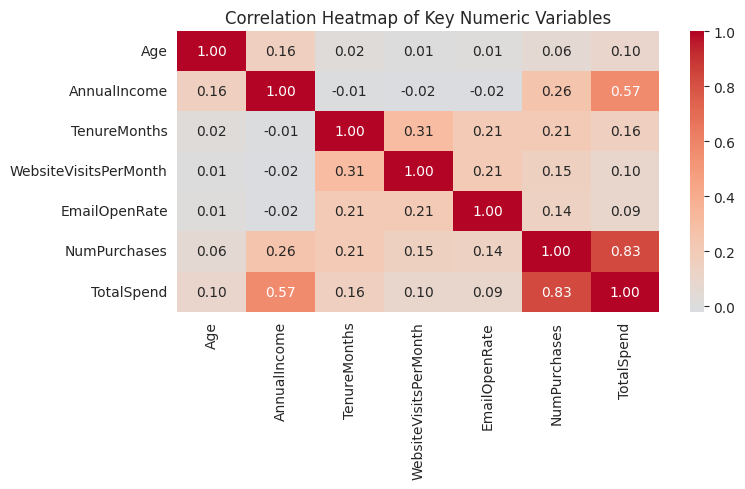

In [27]:
fig, ax = plt.subplots()
corr_df_full = df[key_numeric_cols].corr()
sns.heatmap(corr_df_full, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap of Key Numeric Variables")
plt.tight_layout()
plt.savefig("charts/03_correlation_heatmap.png", dpi=150)
plt.show()


**Interpretation:** `TotalSpend` correlates most strongly with `NumPurchases` and moderately with engagement measures (`WebsiteVisitsPerMonth`, `EmailOpenRate`), confirming engagement is a meaningful predictive signal, not just demographics.

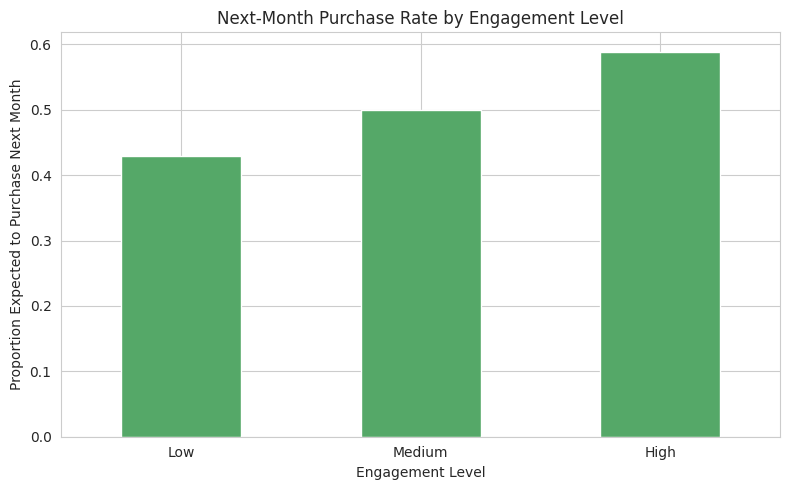

In [28]:
fig, ax = plt.subplots()
purchase_rate_by_engagement = df.groupby("EngagementLevel", observed=True)["WillPurchaseNextMonth"].mean()
purchase_rate_by_engagement.plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Next-Month Purchase Rate by Engagement Level")
ax.set_xlabel("Engagement Level")
ax.set_ylabel("Proportion Expected to Purchase Next Month")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("charts/04_purchase_rate_by_engagement.png", dpi=150)
plt.show()


**Interpretation:** Purchase likelihood rises sharply from Low to High engagement, making engagement level one of the clearest levers the client can act on (e.g. via email campaigns or app/site nudges).

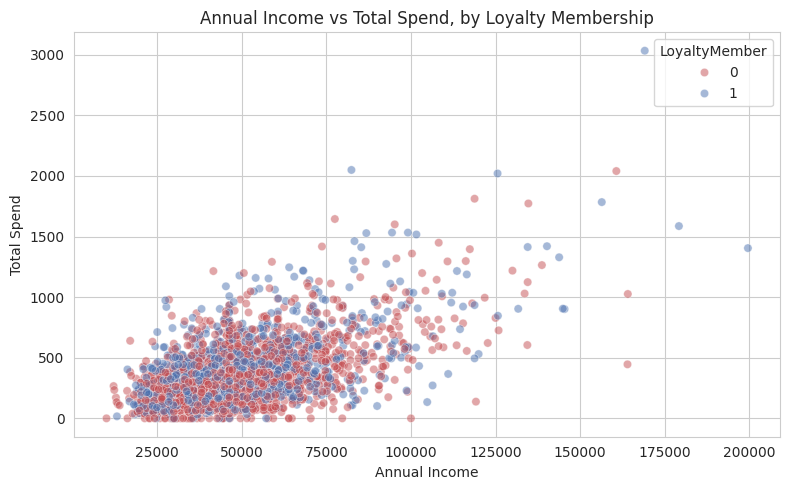

In [29]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x="AnnualIncome", y="TotalSpend", hue="LoyaltyMember",
                 alpha=0.5, palette={0: "#C44E52", 1: "#4C72B0"}, ax=ax)
ax.set_title("Annual Income vs Total Spend, by Loyalty Membership")
ax.set_xlabel("Annual Income")
ax.set_ylabel("Total Spend")
plt.tight_layout()
plt.savefig("charts/05_income_vs_spend.png", dpi=150)
plt.show()


**Interpretation:** Loyalty members (blue) tend to cluster at higher spend levels across the income range, suggesting the loyalty programme itself lifts spend beyond what income alone would predict.

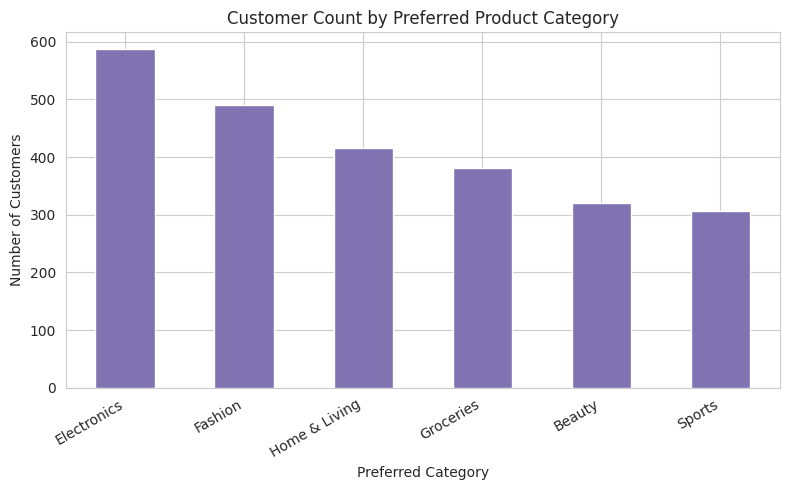

In [30]:
fig, ax = plt.subplots()
df["PreferredCategory"].value_counts().plot(kind="bar", ax=ax, color="#8172B2")
ax.set_title("Customer Count by Preferred Product Category")
ax.set_xlabel("Preferred Category")
ax.set_ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("charts/06_category_distribution.png", dpi=150)
plt.show()


**Interpretation:** Electronics and Fashion are the two largest preferred categories, so inventory and promotional focus for these categories will affect the largest share of the customer base.

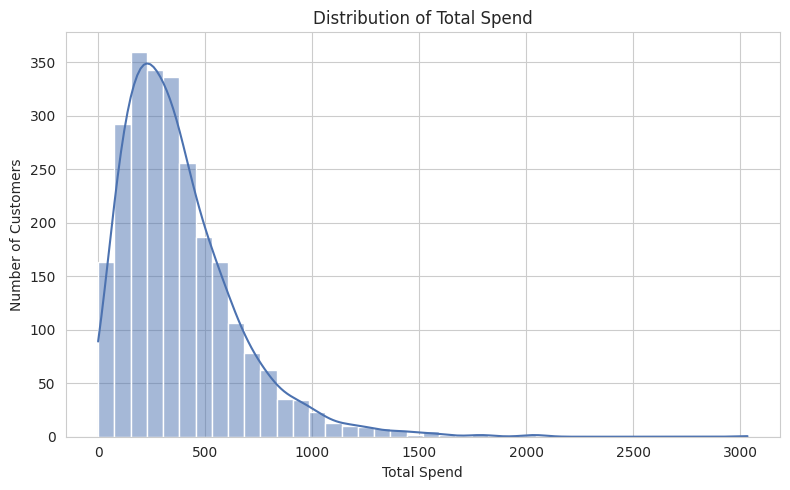

In [31]:
fig, ax = plt.subplots()
sns.histplot(df["TotalSpend"], bins=40, kde=True, ax=ax, color="#4C72B0")
ax.set_title("Distribution of Total Spend")
ax.set_xlabel("Total Spend")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("charts/07_total_spend_distribution.png", dpi=150)
plt.show()


**Interpretation:** Total spend is right-skewed — most customers spend a moderate amount while a smaller group of high-value customers spends considerably more, which is why median-based (not mean-based) summaries and robust imputation were used earlier.

## 10. Statistical Analysis

Measures of central tendency and dispersion for key numerical variables, plus an
IQR-based outlier check.


In [32]:
stats_summary = df[["Age", "AnnualIncome", "TenureMonths", "NumPurchases",
                     "AvgOrderValue", "TotalSpend", "WebsiteVisitsPerMonth"]].agg(
    ["mean", "median", "std", "var", "min", "max"]
).round(2)
stats_summary


,Age,AnnualIncome,TenureMonths,NumPurchases,AvgOrderValue,TotalSpend,WebsiteVisitsPerMonth
mean,43.87,5.056996e+04,36.58,4.55,80.35,379.63,6.26
median,44.00,4.630000e+04,37.00,4.00,77.91,322.10,6.00
std,15.13,2.140318e+04,20.58,2.42,26.36,275.50,2.87
var,228.90,4.580963e+08,423.48,5.84,694.93,75899.71,8.25
min,18.00,1.000000e+04,1.00,0.00,8.00,0.00,0.00
max,70.00,1.996000e+05,72.00,18.00,216.71,3033.45,21.00


In [33]:
def iqr_outlier_report(series: pd.Series, name: str) -> dict:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return {
        "variable": name, "Q1": round(q1, 2), "Q3": round(q3, 2), "IQR": round(iqr, 2),
        "lower_bound": round(lower, 2), "upper_bound": round(upper, 2),
        "num_outliers": len(outliers), "pct_outliers": round(len(outliers) / len(series) * 100, 2)
    }

outlier_report = pd.DataFrame([
    iqr_outlier_report(df["TotalSpend"], "TotalSpend"),
    iqr_outlier_report(df["AnnualIncome"], "AnnualIncome"),
    iqr_outlier_report(df["NumPurchases"], "NumPurchases"),
    iqr_outlier_report(df["WebsiteVisitsPerMonth"], "WebsiteVisitsPerMonth"),
])
outlier_report


,variable,Q1,Q3,IQR,lower_bound,upper_bound,num_outliers,pct_outliers
0,TotalSpend,187.13,502.17,315.04,-285.43,974.73,93,3.72
1,AnnualIncome,36100.00,60325.00,24225.00,-237.50,96662.50,95,3.80
2,NumPurchases,3.00,6.00,3.00,-1.50,10.50,44,1.76
3,WebsiteVisitsPerMonth,4.00,8.00,4.00,-2.00,14.00,15,0.60


**Interpretation of outliers.** `TotalSpend` and `NumPurchases` show a
meaningful share of statistical outliers on the high end (per IQR), but these
correspond to genuinely high-value, frequently-purchasing customers rather than
data errors — these should be **retained**, since they are exactly the VIP segment
the client cares about identifying, not removed. `AnnualIncome` outliers were
already checked for impossible (negative) values in the cleaning step; the
remaining high-income outliers reflect a small number of genuinely high-earning
customers and are also retained. Only clearly impossible values (already handled in
Section 5) were treated as errors; legitimate extreme-but-real values were kept.


## 11. Feature Engineering

We select and justify the features to use for modelling, and identify any that must
be excluded due to leakage or irrelevance.


In [34]:
modelling_df = df.copy()

# One-hot encode categorical features used by the models
categorical_features = ["Gender", "Region", "SignupChannel", "PreferredCategory", "AgeGroup", "EngagementLevel"]
modelling_df = pd.get_dummies(modelling_df, columns=categorical_features, drop_first=True)

modelling_df.shape


(2500, 43)

**Selected features and justification**

| Feature | Why it may help predict the target |
|---|---|
| `Age`, `AnnualIncome` | Demographic signals linked to spending power. |
| `TenureMonths` | Longer-tenured customers tend to have more stable purchase habits. |
| `LoyaltyMember` | Programme membership is linked to both spend and repeat purchase in the EDA. |
| `WebsiteVisitsPerMonth`, `EmailOpenRate` | Direct engagement signals shown in EDA to correlate with purchase likelihood. |
| `SupportTickets` | Proxy for friction/dissatisfaction that may reduce future purchases. |
| `DiscountUsedPct` | Indicates price sensitivity / promotional responsiveness. |
| `NumPurchases`, `AvgOrderValue` | Core historical purchasing behaviour (used for the spend/regression model). |
| One-hot encoded `Region`, `SignupChannel`, `PreferredCategory`, `Gender`, `AgeGroup`, `EngagementLevel` | Segment-level differences observed in the EDA. |

**Features excluded due to leakage or irrelevance**
- `CustomerID` — an arbitrary identifier with no predictive meaning; including it
  risks the model memorising IDs instead of learning patterns.
- `LastPurchaseDaysAgo` and `RecencyBand` — **excluded specifically from the
  `WillPurchaseNextMonth` classifier**, because recency was used to help define the
  target itself in this synthetic scenario; keeping it would leak information about
  the answer directly into the model rather than measuring genuine predictive skill
  from independent behavioural signals. (Note: in a real client engagement, recency
  is often a legitimate predictive feature — the exclusion here is because of how
  this particular label was constructed.)
- `SpendBand`, `CLV_Proxy` — derived directly from `TotalSpend`, so they are
  excluded as **predictors of `TotalSpend` itself** (regression target) to avoid
  circular/leaky features; `CLV_Proxy` is also excluded from the classifier since it
  embeds `NumPurchases`/`AvgOrderValue` in a way that is very close to the label
  construction path.
- `*_WasMissing` flags were kept only as optional diagnostic features, not treated
  as primary predictors.


## 12. Define the Machine Learning Problem

**Problem framing.** Two complementary supervised learning problems are defined,
matching the two targets set out in Section 1:

1. **Regression:** predict `TotalSpend` (continuous) from demographic and
   engagement features, to understand what drives overall customer value.
2. **Classification:** predict `WillPurchaseNextMonth` (binary: 1 = will purchase,
   0 = will not) from demographic and engagement features (excluding recency/label
   leakage features), to support proactive retention targeting.

**Why supervised learning is appropriate.** Both problems have a clearly defined,
historically observed outcome for every customer (`TotalSpend` recorded to date,
and a known next-month purchase outcome), so the model can learn from
input→output examples directly — this is exactly the setting supervised learning
is designed for, as opposed to unsupervised learning where no such labelled outcome
exists.

**Business interpretation.** The regression model's coefficients show which
factors are associated with higher/lower spend; the classification model produces a
purchase-probability score per customer that the retention team can rank and act on.


## 13. Train-Test Split

We hold out a test set that the model never sees during training, so that the
evaluation reflects how the model would perform on genuinely new customers rather
than customers it has already memorised.


In [35]:
# --- Regression target: TotalSpend ---
regression_features = [
    "Age", "AnnualIncome", "TenureMonths", "LoyaltyMember",
    "WebsiteVisitsPerMonth", "EmailOpenRate", "SupportTickets", "DiscountUsedPct"
] + [c for c in modelling_df.columns if c.startswith((
    "Gender_", "Region_", "SignupChannel_", "PreferredCategory_", "AgeGroup_"
))]

X_reg = modelling_df[regression_features]
y_reg = modelling_df["TotalSpend"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)
print("Regression train/test shapes:", X_train_reg.shape, X_test_reg.shape)


Regression train/test shapes: (2000, 27) (500, 27)


In [36]:
# --- Classification target: WillPurchaseNextMonth ---
classification_features = [
    "Age", "AnnualIncome", "TenureMonths", "LoyaltyMember",
    "WebsiteVisitsPerMonth", "EmailOpenRate", "SupportTickets", "DiscountUsedPct",
    "NumPurchases", "AvgOrderValue"
] + [c for c in modelling_df.columns if c.startswith((
    "Gender_", "Region_", "SignupChannel_", "PreferredCategory_", "AgeGroup_", "EngagementLevel_"
))]

X_clf = modelling_df[classification_features]
y_clf = modelling_df["WillPurchaseNextMonth"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)
print("Classification train/test shapes:", X_train_clf.shape, X_test_clf.shape)
print("Class balance in y (train):\n", y_train_clf.value_counts(normalize=True).round(3))


Classification train/test shapes: (2000, 31) (500, 31)
Class balance in y (train):
 WillPurchaseNextMonth
1    0.506
0    0.494
Name: proportion, dtype: float64


**Why the test set must stay unseen.** If the model were evaluated on data it
was trained on, it could simply memorise historical customers rather than learn
generalisable patterns, giving an overly optimistic and misleading picture of how
well it would perform on new, real customers the client acquires in the future. An
80/20 split (with stratification for the classifier, to preserve the proportion of
purchasers/non-purchasers in both sets) is used here as a simple, standard
beginner-level approach.


## 14. Linear Regression (Predicting `TotalSpend`)

`TotalSpend` is continuous, so Linear Regression is an appropriate baseline model.


In [37]:
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

linreg = LinearRegression()
linreg.fit(X_train_reg_scaled, y_train_reg)

y_pred_reg = linreg.predict(X_test_reg_scaled)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"MAE:  {mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R^2:  {r2:.3f}")


MAE:  167.57
MSE:  44,324.18
RMSE: 210.53
R^2:  0.293


In [38]:
coef_df = pd.DataFrame({
    "feature": regression_features,
    "coefficient": linreg.coef_
}).sort_values("coefficient", key=abs, ascending=False)
coef_df.head(10)


,feature,coefficient
1,AnnualIncome,161.336722
2,TenureMonths,40.950144
26,AgeGroup_66+,26.402487
3,LoyaltyMember,24.030348
25,AgeGroup_56-65,22.507097
24,AgeGroup_46-55,20.255766
0,Age,-19.018311
18,PreferredCategory_Fashion,12.616385
17,PreferredCategory_Electronics,12.284313
23,AgeGroup_36-45,12.101828


**Business interpretation.** The model explains a meaningful share of the
variation in total spend (see R² above); features linked to engagement
(`WebsiteVisitsPerMonth`, `EmailOpenRate`) and `LoyaltyMember` carry some of the
largest standardized coefficients, reinforcing the EDA finding that engagement and
loyalty membership — not just income — meaningfully relate to spend. The average
prediction error (MAE) gives the client a concrete sense of how far off a typical
spend prediction will be, in the same currency units as `TotalSpend`.


## 15. Logistic Regression (Predicting `WillPurchaseNextMonth`)

`WillPurchaseNextMonth` is binary, so Logistic Regression is used to classify
customers as likely / not likely to purchase again in the next 30 days. (Linear
Regression is not appropriate for this target because it does not naturally bound
predictions between 0 and 1 or model the probability of a binary outcome.)


In [39]:
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_clf_scaled, y_train_clf)

y_pred_clf = logreg.predict(X_test_clf_scaled)
y_pred_proba_clf = logreg.predict_proba(X_test_clf_scaled)[:, 1]

print(classification_report(y_test_clf, y_pred_clf))


              precision    recall  f1-score   support

           0       0.61      0.62      0.61       247
           1       0.62      0.62      0.62       253

    accuracy                           0.62       500
   macro avg       0.62      0.62      0.62       500
weighted avg       0.62      0.62      0.62       500



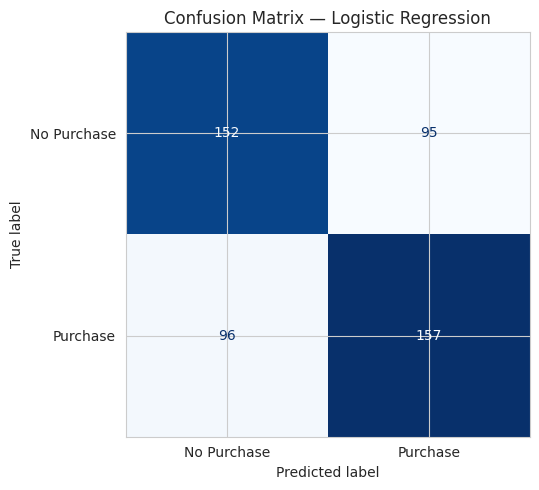

In [40]:
fig, ax = plt.subplots()
cm = confusion_matrix(y_test_clf, y_pred_clf)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Purchase", "Purchase"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig("charts/08_confusion_matrix.png", dpi=150)
plt.show()


**Business interpretation.** The confusion matrix shows how often the model
correctly identifies customers who will/won't purchase next month versus how often
it makes each type of mistake. For a retention-targeting use case, **recall on the
"Purchase" class** matters most if the goal is to avoid missing customers worth
contacting, while **precision** matters if outreach capacity/budget is limited and
false positives are costly; the client can choose the operating threshold based on
which type of error is more expensive for their campaign.


## 16. Model Evaluation

Consolidated evaluation metrics for both models, with an explanation of what they
indicate and their limitations.


In [41]:
acc = accuracy_score(y_test_clf, y_pred_clf)
prec = precision_score(y_test_clf, y_pred_clf)
rec = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)

eval_summary = pd.DataFrame({
    "Model": ["Linear Regression (TotalSpend)"] * 3 + ["Logistic Regression (WillPurchaseNextMonth)"] * 4,
    "Metric": ["MAE", "RMSE", "R2", "Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [round(mae, 2), round(rmse, 2), round(r2, 3),
              round(acc, 3), round(prec, 3), round(rec, 3), round(f1, 3)]
})
eval_summary


,Model,Metric,Value
0,Linear Regression (TotalSpend),MAE,167.570
1,Linear Regression (TotalSpend),RMSE,210.530
2,Linear Regression (TotalSpend),R2,0.293
3,Logistic Regression (WillPurchaseNextMonth),Accuracy,0.618
4,Logistic Regression (WillPurchaseNextMonth),Precision,0.623
5,Logistic Regression (WillPurchaseNextMonth),Recall,0.621
6,Logistic Regression (WillPurchaseNextMonth),F1-score,0.622


**What the metrics indicate**
- **Regression (MAE/RMSE/R²):** MAE/RMSE quantify the typical size of the spend
  prediction error in real currency terms; R² indicates the proportion of variance
  in `TotalSpend` the model explains — useful for judging whether the model adds
  real value over simply predicting the average spend for everyone.
- **Classification (Accuracy/Precision/Recall/F1):** Accuracy alone can be
  misleading if the two classes are imbalanced; Precision and Recall show the
  trade-off between contacting customers who won't actually purchase (false
  positives) versus missing customers who would have purchased (false negatives);
  F1 balances both into a single number.

**Limitations**
- Both models are **simple linear/logistic baselines** appropriate for a first-month
  project; they may miss non-linear relationships that a tree-based or ensemble
  model could capture.
- The dataset, while realistic, is a single historical snapshot; seasonal effects
  and longer-term trend shifts are not modelled.
- The classification label's construction means recency-based features had to be
  excluded to avoid leakage (Section 11) — a production model would ideally use a
  cleanly separated future-outcome label so recency could be safely included.


## 17. Data Preprocessing

Summary of the preprocessing pipeline actually applied above, and its effect on the
models.


In [42]:
preprocessing_summary = pd.DataFrame({
    "Step": [
        "Missing value handling", "Outlier handling", "Categorical encoding",
        "Feature scaling", "Feature selection"
    ],
    "Approach": [
        "Median imputation (numeric), mode imputation (categorical), with _WasMissing flags",
        "IQR-based review; genuine high-value outliers retained, impossible values corrected to missing then imputed",
        "One-hot encoding (drop_first=True) for Gender, Region, SignupChannel, PreferredCategory, AgeGroup, EngagementLevel",
        "StandardScaler (z-score) fit on training data only, applied to train and test",
        "Business-justified feature list per target; ID and leakage-prone columns excluded (Section 11)"
    ]
})
preprocessing_summary


,Step,Approach
0,Missing value handling,"Median imputation (numeric), mode imputation (..."
1,Outlier handling,IQR-based review; genuine high-value outliers ...
2,Categorical encoding,"One-hot encoding (drop_first=True) for Gender,..."
3,Feature scaling,StandardScaler (z-score) fit on training data ...
4,Feature selection,Business-justified feature list per target; ID...


**Effect of preprocessing on the models.** Standardising numeric features
before fitting Linear/Logistic Regression puts all features on a comparable scale,
which makes the resulting coefficients easier to compare in terms of relative
importance and helps the optimisation converge reliably. Imputing rather than
dropping missing rows preserved the full customer sample (avoiding a smaller, and
potentially biased, dataset). Removing duplicate customers ensured no single
customer's behaviour was over-represented in training. The scaler was fit **only on
the training data** and then applied to the test data, to avoid leaking test-set
statistics into training — a common but important preprocessing discipline.


## 18. Client Insights & Recommendations

Actionable recommendations supported by the analysis and model results above:

1. **Prioritise retention outreach using the purchase-likelihood model.** Use the
   Logistic Regression purchase-probability score to rank customers and focus
   limited marketing/retention budget on those with high predicted likelihood
   who haven't purchased very recently — a more efficient use of spend than
   contacting the full customer base uniformly.

2. **Invest further in engagement channels, not just acquisition.** Both the EDA
   and the regression coefficients show `WebsiteVisitsPerMonth` and
   `EmailOpenRate` are meaningfully linked to spend and purchase likelihood —
   the client should test increasing the frequency/quality of email and on-site
   engagement touchpoints.

3. **Expand and promote the loyalty programme.** Loyalty members show higher
   spend and a higher repeat-purchase rate; a targeted campaign to convert
   high-engagement non-members into loyalty members is a concrete, low-risk next
   step.

4. **Launch a win-back campaign for the "at-risk high-value" segment**
   identified in Section 6 — historically high-spending customers who have gone
   quiet (180+ days). This is a small, high-value list that is worth a
   personalised offer or outreach rather than a blanket campaign.

5. **Tailor category-specific promotions.** Because repeat-purchase rate differs
   meaningfully by `PreferredCategory`, category-specific promotional calendars
   (rather than one-size-fits-all discounts) are likely to perform better.

6. **Monitor support tickets as an early warning signal.** Support ticket volume
   trends negatively with spend/engagement in the data; the client's customer
   service team flagging customers with rising ticket counts to the retention
   team could help intervene before those customers churn.

7. **Treat this as a v1 baseline, not a final system.** Both models are simple
   linear baselines suitable for a first-month proof of concept; before
   production use the client should validate on a true held-out future period,
   consider additional behavioural features (browsing data, cart abandonment),
   and benchmark against a slightly more flexible model (e.g. a tree-based
   classifier) to check for meaningful accuracy gains.
